## Cell 1 — Install & Import
Only image and plotting libraries — zero crypto imports.

In [1]:
!pip install pillow numpy matplotlib --quiet

from PIL import Image
import numpy as np
import os, time
import matplotlib.pyplot as plt

print("Ready.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Ready.


## Cell 2 — DES Tables
All the lookup tables that define how DES rearranges and substitutes bits.
These are fixed constants — part of the DES standard.

In [2]:
# ── Permutation Tables ──────────────────────────────────────────

# IP: shuffles the 64 input bits before the 16 rounds start
IP = [
    58,50,42,34,26,18,10, 2, 60,52,44,36,28,20,12, 4,
    62,54,46,38,30,22,14, 6, 64,56,48,40,32,24,16, 8,
    57,49,41,33,25,17, 9, 1, 59,51,43,35,27,19,11, 3,
    61,53,45,37,29,21,13, 5, 63,55,47,39,31,23,15, 7
]

# IP_INV: un-shuffles the bits after all 16 rounds
IP_INV = [
    40, 8,48,16,56,24,64,32, 39, 7,47,15,55,23,63,31,
    38, 6,46,14,54,22,62,30, 37, 5,45,13,53,21,61,29,
    36, 4,44,12,52,20,60,28, 35, 3,43,11,51,19,59,27,
    34, 2,42,10,50,18,58,26, 33, 1,41, 9,49,17,57,25
]

# PC1: picks 56 bits from the 64-bit key (drops 8 parity bits)
PC1 = [
    57,49,41,33,25,17, 9,  1,58,50,42,34,26,18,
    10, 2,59,51,43,35,27, 19,11, 3,60,52,44,36,
    63,55,47,39,31,23,15,  7,62,54,46,38,30,22,
    14, 6,61,53,45,37,29, 21,13, 5,28,20,12, 4
]

# PC2: picks 48 bits from the 56-bit shifted key (makes each round subkey)
PC2 = [
    14,17,11,24, 1, 5,  3,28,15, 6,21,10,
    23,19,12, 4,26, 8, 16, 7,27,20,13, 2,
    41,52,31,37,47,55, 30,40,51,45,33,48,
    44,49,39,56,34,53, 46,42,50,36,29,32
]

# E: expands the 32-bit right half to 48 bits so it matches the subkey size
E_DEF = [
    32, 1, 2, 3, 4, 5,  4, 5, 6, 7, 8, 9,
     8, 9,10,11,12,13, 12,13,14,15,16,17,
    16,17,18,19,20,21, 20,21,22,23,24,25,
    24,25,26,27,28,29, 28,29,30,31,32, 1
]

# P: shuffles the 32-bit output of the S-boxes
P_DEF = [
    16, 7,20,21, 29,12,28,17,  1,15,23,26,  5,18,31,10,
     2, 8,24,14, 32,27, 3, 9, 19,13,30, 6, 22,11, 4,25
]

# How many positions to left-rotate the key halves each round
SHIFTS = [1,1,2,2,2,2,2,2,1,2,2,2,2,2,2,1]

# ── S-Boxes ────────────────────────────────────────────────────
# 8 boxes that each turn 6 bits into 4 bits — the core of DES security
SBOXES = [
    [[14, 4,13, 1, 2,15,11, 8, 3,10, 6,12, 5, 9, 0, 7],  # S1
     [ 0,15, 7, 4,14, 2,13, 1,10, 6,12,11, 9, 5, 3, 8],
     [ 4, 1,14, 8,13, 6, 2,11,15,12, 9, 7, 3,10, 5, 0],
     [15,12, 8, 2, 4, 9, 1, 7, 5,11, 3,14,10, 0, 6,13]],
    [[15, 1, 8,14, 6,11, 3, 4, 9, 7, 2,13,12, 0, 5,10],  # S2
     [ 3,13, 4, 7,15, 2, 8,14,12, 0, 1,10, 6, 9,11, 5],
     [ 0,14, 7,11,10, 4,13, 1, 5, 8,12, 6, 9, 3, 2,15],
     [13, 8,10, 1, 3,15, 4, 2,11, 6, 7,12, 0, 5,14, 9]],
    [[10, 0, 9,14, 6, 3,15, 5, 1,13,12, 7,11, 4, 2, 8],  # S3
     [13, 7, 0, 9, 3, 4, 6,10, 2, 8, 5,14,12,11,15, 1],
     [13, 6, 4, 9, 8,15, 3, 0,11, 1, 2,12, 5,10,14, 7],
     [ 1,10,13, 0, 6, 9, 8, 7, 4,15,14, 3,11, 5, 2,12]],
    [[ 7,13,14, 3, 0, 6, 9,10, 1, 2, 8, 5,11,12, 4,15],  # S4
     [13, 8,11, 5, 6,15, 0, 3, 4, 7, 2,12, 1,10,14, 9],
     [10, 6, 9, 0,12,11, 7,13,15, 1, 3,14, 5, 2, 8, 4],
     [ 3,15, 0, 6,10, 1,13, 8, 9, 4, 5,11,12, 7, 2,14]],
    [[ 2,12, 4, 1, 7,10,11, 6, 8, 5, 3,15,13, 0,14, 9],  # S5
     [14,11, 2,12, 4, 7,13, 1, 5, 0,15,10, 3, 9, 8, 6],
     [ 4, 2, 1,11,10,13, 7, 8,15, 9,12, 5, 6, 3, 0,14],
     [11, 8,12, 7, 1,14, 2,13, 6,15, 0, 9,10, 4, 5, 3]],
    [[12, 1,10,15, 9, 2, 6, 8, 0,13, 3, 4,14, 7, 5,11],  # S6
     [10,15, 4, 2, 7,12, 9, 5, 6, 1,13,14, 0,11, 3, 8],
     [ 9,14,15, 5, 2, 8,12, 3, 7, 0, 4,10, 1,13,11, 6],
     [ 4, 3, 2,12, 9, 5,15,10,11,14, 1, 7, 6, 0, 8,13]],
    [[ 4,11, 2,14,15, 0, 8,13, 3,12, 9, 7, 5,10, 6, 1],  # S7
     [13, 0,11, 7, 4, 9, 1,10,14, 3, 5,12, 2,15, 8, 6],
     [ 1, 4,11,13,12, 3, 7,14,10,15, 6, 8, 0, 5, 9, 2],
     [ 6,11,13, 8, 1, 4,10, 7, 9, 5, 0,15,14, 2, 3,12]],
    [[13, 2, 8, 4, 6,15,11, 1,10, 9, 3,14, 5, 0,12, 7],  # S8
     [ 1,15,13, 8,10, 3, 7, 4,12, 5, 6,11, 0,14, 9, 2],
     [ 7,11, 4, 1, 9,12,14, 2, 0, 6,10,13,15, 3, 5, 8],
     [ 2, 1,14, 7, 4,10, 8,13,15,12, 9, 0, 3, 5, 6,11]],
]

print("All DES tables loaded.")

All DES tables loaded.


## Cell 3 — Precomputed Lookup Tables
A speed trick so larger images encrypt in reasonable time.

For each permutation table (IP, E, PC1, PC2), we pre-calculate every possible byte input's contribution to the output, storing results in a list. Then instead of looping over bits, we do a few list lookups.

The **SP table** combines S-box + P permutation into one lookup — reducing 16 rounds × 256 bit-ops down to 16 × 8 list lookups.

In [3]:
def _build_byte_tables(perm, in_bits, out_bits):
    """Pre-calculate each input byte's contribution to the permuted output."""
    tables = []
    for byte_idx in range(in_bits // 8):
        t = [0] * 256
        for byte_val in range(256):
            result = 0
            for bit_pos in range(8):
                in_bit = byte_idx * 8 + bit_pos + 1   # 1-indexed position in full input
                if (byte_val >> (7 - bit_pos)) & 1:   # if this bit is set
                    for out_idx, p_val in enumerate(perm):
                        if p_val == in_bit:
                            result |= 1 << (out_bits - 1 - out_idx)
            t[byte_val] = result
        tables.append(t)
    return tables

def _apply(val, tables, in_bits):
    """Apply precomputed byte tables to an integer."""
    result = 0
    for i, t in enumerate(tables):
        result |= t[(val >> (in_bits - 8*(i+1))) & 0xFF]
    return result

def _build_sp_table():
    """Combine S-box substitution + P permutation into one lookup table."""
    def int_perm(val, table, in_bits):
        r = 0
        for i, t in enumerate(table):
            r |= ((val >> (in_bits - t)) & 1) << (len(table) - 1 - i)
        return r

    sp = []
    for box in range(8):
        t = [0] * 64
        for x in range(64):
            row  = ((x & 0x20) >> 4) | (x & 0x01)   # first and last bit
            col  = (x >> 1) & 0x0F                   # middle four bits
            sval = SBOXES[box][row][col]              # 4-bit S-box output
            p_in = sval << (28 - 4 * box)            # place bits for P input
            t[x] = int_perm(p_in, P_DEF, 32)         # apply P permutation
        sp.append(t)
    return sp

print("Building tables (one-time cost)...")
t0 = time.time()

IP_LUT    = _build_byte_tables(IP,    64, 64)
IPINV_LUT = _build_byte_tables(IP_INV,64, 64)
PC1_LUT   = _build_byte_tables(PC1,   64, 56)
PC2_LUT   = _build_byte_tables(PC2,   56, 48)
E_LUT     = _build_byte_tables(E_DEF, 32, 48)
SP        = _build_sp_table()

do_ip    = lambda v: _apply(v, IP_LUT,    64)
do_ipinv = lambda v: _apply(v, IPINV_LUT, 64)
do_pc1   = lambda v: _apply(v, PC1_LUT,   64)
do_pc2   = lambda v: _apply(v, PC2_LUT,   56)
do_e     = lambda v: _apply(v, E_LUT,     32)

print(f"Done in {(time.time()-t0)*1000:.0f} ms.")

Building tables (one-time cost)...
Done in 68 ms.


## Cell 4 — DES Key Setup
The key is entered as plain text. We take exactly the first 8 characters (or pad with zeros if shorter). No hashing — pure DES key handling.

DES then generates **16 subkeys** from this master key, one per round:
- Apply PC1 → 56 bits (parity bits removed)
- Split into C (left 28 bits) and D (right 28 bits)
- Each round: rotate C and D left → apply PC2 → 48-bit subkey

In [4]:
def make_des_key(passphrase):
    """
    Convert a passphrase into an 8-byte DES key.
    Takes the first 8 bytes; pads with zeros if shorter.
    No hashing — purely DES-standard key handling.
    """
    raw = passphrase.encode('utf-8')[:8]   # take up to 8 bytes
    return raw.ljust(8, b'\x00')          # zero-pad if less than 8 bytes

def rotate28(v, n):
    """Circular left rotation of a 28-bit integer by n positions."""
    return ((v << n) | (v >> (28 - n))) & 0x0FFFFFFF

def generate_subkeys(key_8bytes):
    """
    Generate 16 x 48-bit subkeys from the 8-byte DES key.
    These subkeys are used one per round during encryption.
    """
    key_int = int.from_bytes(key_8bytes, 'big')  # treat 8 bytes as one big integer
    key56   = do_pc1(key_int)                    # drop parity bits: 64 -> 56 bits
    C = (key56 >> 28) & 0x0FFFFFFF              # left  28 bits
    D =  key56        & 0x0FFFFFFF              # right 28 bits

    subkeys = []
    for shift in SHIFTS:                         # one iteration per round
        C = rotate28(C, shift)                   # rotate both halves
        D = rotate28(D, shift)
        subkeys.append(do_pc2((C << 28) | D))   # PC2: 56 -> 48 bits = one subkey
    return subkeys

print("DES key functions defined.")

DES key functions defined.


## Cell 5 — Round Function F
Called once per round. Takes the 32-bit right half and the 48-bit subkey:

```
R (32 bits)
  → E table: expand to 48 bits  (some bits repeated so size matches subkey)
  → XOR with 48-bit subkey
  → 8 S-boxes: compress 48 bits back to 32 bits  (the scrambling step)
  → P permutation: shuffle the 32 bits
  = 32-bit result
```
With our SP table, the last two steps (S-boxes + P) are just 8 list lookups.

In [5]:
def f_function(R, subkey):
    """
    DES round function F(R, subkey):
    Expand -> XOR -> S-boxes -> P permutation.
    """
    xored = do_e(R) ^ subkey          # expand R (32->48 bits) then XOR with subkey

    # Pass 8 groups of 6 bits through precomputed S+P table
    return (SP[0][(xored >> 42) & 0x3F] |
            SP[1][(xored >> 36) & 0x3F] |
            SP[2][(xored >> 30) & 0x3F] |
            SP[3][(xored >> 24) & 0x3F] |
            SP[4][(xored >> 18) & 0x3F] |
            SP[5][(xored >> 12) & 0x3F] |
            SP[6][(xored >>  6) & 0x3F] |
            SP[7][ xored        & 0x3F])

print("Round function F defined.")

Round function F defined.


## Cell 6 — DES Block Encrypt / Decrypt
Encrypts or decrypts exactly one 8-byte block through 16 Feistel rounds.

```
Block (8 bytes)
  → IP (initial permutation)
  → Split: L = left 32 bits,  R = right 32 bits
  → Round 1:   new_L = R,   new_R = L XOR F(R, K1)
  → Round 2:   new_L = R,   new_R = L XOR F(R, K2)
  →  ...  (16 rounds total)
  → Swap L and R
  → IP_INV (undo initial permutation)
  → Encrypted block (8 bytes)
```
**Decryption** is identical — just the subkeys are fed in **reverse order** (K16 → K1).

In [6]:
def des_block_encrypt(block_8bytes, subkeys):
    """Encrypt one 8-byte block. Pass subkeys forward (K1..K16)."""
    v    = int.from_bytes(block_8bytes, 'big')
    v    = do_ip(v)                              # initial permutation
    L, R = (v >> 32) & 0xFFFFFFFF, v & 0xFFFFFFFF

    for sk in subkeys:                           # 16 Feistel rounds
        L, R = R, L ^ f_function(R, sk)

    result = do_ipinv((R << 32) | L)             # swap then inverse permutation
    return result.to_bytes(8, 'big')

def des_block_decrypt(block_8bytes, subkeys):
    """Decrypt one 8-byte block. Subkeys must be reversed (K16..K1)."""
    return des_block_encrypt(block_8bytes, list(reversed(subkeys)))

print("DES block encrypt/decrypt defined.")

DES block encrypt/decrypt defined.


## Cell 7 — CBC Mode & PKCS\#7 Padding

### Why padding?
DES needs data length to be a multiple of 8 bytes. PKCS\#7 padding adds bytes at the end, each byte's value = how many bytes were added.
```
Data: [A B C D E]  (5 bytes, need 3 more)
After pad: [A B C D E 03 03 03]  (8 bytes)
```

### Why CBC?
Without CBC (ECB mode), identical image pixels → identical encrypted blocks → pattern visible.
CBC XORs each block with the previous encrypted block, making every block unique:
```
C[0] = DES_enc( P[0] XOR IV  )
C[1] = DES_enc( P[1] XOR C[0] )
C[2] = DES_enc( P[2] XOR C[1] )  ...and so on
```
The **IV** (Initialization Vector) is a random 8-byte starting value.

In [7]:
def pkcs7_pad(data):
    """Pad data so its length is a multiple of 8 bytes."""
    pad_len = 8 - (len(data) % 8)
    return data + bytes([pad_len] * pad_len)

def pkcs7_unpad(data):
    """Remove the padding bytes added by pkcs7_pad."""
    return data[:-data[-1]]

def des_cbc_encrypt(plaintext, subkeys):
    """Encrypt bytes using DES in CBC mode. Returns (IV, ciphertext)."""
    iv      = os.urandom(8)          # random starting block (DES-generated randomness)
    padded  = pkcs7_pad(plaintext)
    cipher  = b''
    prev    = iv
    total   = len(padded) // 8

    for i in range(total):
        block = padded[i*8 : i*8+8]
        xored = bytes(a ^ b for a, b in zip(block, prev))  # CBC: XOR with previous
        enc   = des_block_encrypt(xored, subkeys)
        cipher += enc
        prev   = enc
        if (i+1) % 500 == 0 or (i+1) == total:
            print(f'  encrypting {i+1}/{total} blocks...', end='\r')
    print()
    return iv, cipher

def des_cbc_decrypt(ciphertext, subkeys, iv):
    """Decrypt bytes using DES in CBC mode."""
    plain = b''
    prev  = iv
    total = len(ciphertext) // 8

    for i in range(total):
        block = ciphertext[i*8 : i*8+8]
        dec   = des_block_decrypt(block, subkeys)
        plain += bytes(a ^ b for a, b in zip(dec, prev))   # CBC: XOR with previous
        prev   = block
        if (i+1) % 500 == 0 or (i+1) == total:
            print(f'  decrypting {i+1}/{total} blocks...', end='\r')
    print()
    return pkcs7_unpad(plain)

print("CBC mode and padding defined.")

CBC mode and padding defined.


## Cell 8 — Image Encrypt / Decrypt
Converts the image to raw bytes, runs DES-CBC on them, and saves the result.

The output file stores a simple text header so decryption knows the image dimensions:
```
[8 bytes: IV][header: RGB|256|256|196608\n][encrypted bytes...]
```

In [8]:
def encrypt_image(src, dst, subkeys):
    img  = Image.open(src)
    mode, (w, h) = img.mode, img.size
    raw  = img.tobytes()                              # image as plain bytes

    print(f'Image: {w}x{h} {mode} = {len(raw):,} bytes = {len(raw)//8:,} blocks')
    t0 = time.perf_counter()
    iv, cipher = des_cbc_encrypt(raw, subkeys)
    elapsed = (time.perf_counter() - t0) * 1000

    with open(dst, 'wb') as f:
        f.write(iv)
        f.write(f'{mode}|{w}|{h}|{len(raw)}\n'.encode())
        f.write(cipher)

    return len(raw), len(cipher), elapsed, iv

def decrypt_image(src, dst, subkeys):
    with open(src, 'rb') as f:
        iv     = f.read(8)
        header = f.readline().decode().strip()
        cipher = f.read()

    mode, w, h, orig_len = header.split('|')
    w, h, orig_len = int(w), int(h), int(orig_len)

    t0  = time.perf_counter()
    raw = des_cbc_decrypt(cipher, subkeys, iv)[:orig_len]
    elapsed = (time.perf_counter() - t0) * 1000

    Image.frombytes(mode, (w, h), raw).save(dst)
    return elapsed

print("Image functions defined.")

Image functions defined.


## Cell 9 — Configuration
Set your key and image size here.


In [9]:
IMAGE_PATH     = 'D:/College/College_Notes/Third_Year/Sixth_Sem/CNS/Projects/bee.png'
ENCRYPTED_PATH = 'encrypted_image.bin'
DECRYPTED_PATH = 'decrypted_image.png'

KEY_STRING  = 'SecretKy'     # max 8 characters — this IS the DES key
IMAGE_SIZE  = 128            # change to 256, 512, etc.

DES_KEY  = make_des_key(KEY_STRING)
SUBKEYS  = generate_subkeys(DES_KEY)

print(f"Key string : {KEY_STRING!r}")
print(f"DES key    : {DES_KEY.hex().upper()}  ({len(DES_KEY)} bytes)")
print(f"Subkeys    : {len(SUBKEYS)} generated (one per round)")

Key string : 'SecretKy'
DES key    : 5365637265744B79  (8 bytes)
Subkeys    : 16 generated (one per round)


## Cell 10 — Load / Create Input Image

Using image: D:/College/College_Notes/Third_Year/Sixth_Sem/CNS/Projects/bee.png


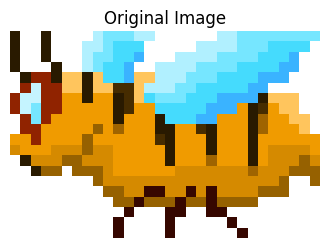

In [10]:
if not os.path.exists(IMAGE_PATH):
    s = IMAGE_SIZE
    arr = np.zeros((s, s, 3), dtype=np.uint8)
    for y in range(s):
        for x in range(s):
            arr[y,x] = [x*255//s, y*255//s, (x+y)*255//(2*s)]
    Image.fromarray(arr,'RGB').save(IMAGE_PATH)
    print(f'Sample {s}x{s} image created: {IMAGE_PATH}')
else:
    print(f'Using image: {IMAGE_PATH}')

plt.figure(figsize=(4,4))
plt.imshow(Image.open(IMAGE_PATH))
plt.title('Original Image'); plt.axis('off'); plt.show()

## Cell 11 — Encrypt the Image

In [11]:
print('--- ENCRYPTION ---')
orig_size, enc_size, enc_ms, iv_used = encrypt_image(IMAGE_PATH, ENCRYPTED_PATH, SUBKEYS)

print(f"\nIV (hex)       : {iv_used.hex().upper()}")
print(f"Original size  : {orig_size:,} bytes")
print(f"Encrypted size : {enc_size:,} bytes")
print(f"Time           : {enc_ms/1000:.2f} s")
print(f"Saved to       : {ENCRYPTED_PATH}")

--- ENCRYPTION ---
Image: 60x40 RGBA = 9,600 bytes = 1,200 blocks
  encrypting 1201/1201 blocks...

IV (hex)       : AADA3233FE4324C2
Original size  : 9,600 bytes
Encrypted size : 9,608 bytes
Time           : 0.06 s
Saved to       : encrypted_image.bin


## Cell 12 — Visualise Encrypted Data
The encrypted bytes are rendered as an image. It must look like **pure noise** — no trace of the original image should be visible.

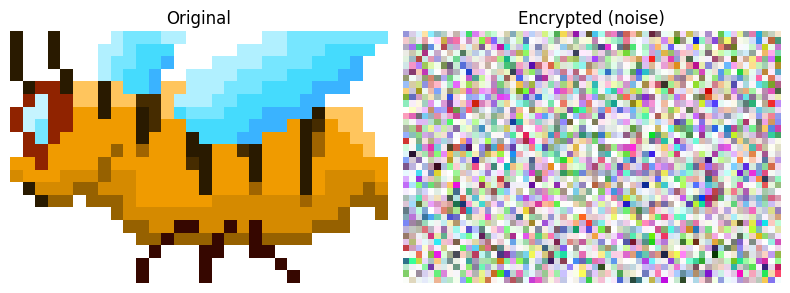

No structure visible — DES-CBC encryption is working correctly.


In [12]:
orig_img = Image.open(IMAGE_PATH)
mode_v, (wv, hv) = orig_img.mode, orig_img.size
ch = {'L':1, 'RGB':3, 'RGBA':4}.get(mode_v, 3)
needed = wv * hv * ch

with open(ENCRYPTED_PATH, 'rb') as f:
    f.read(8); f.readline()          # skip IV and header
    enc_vis_bytes = f.read(needed)

enc_vis_bytes += bytes(max(0, needed - len(enc_vis_bytes)))   # zero-pad if needed
enc_vis = Image.frombytes(mode_v, (wv, hv), enc_vis_bytes[:needed])

fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(orig_img);  ax[0].set_title('Original');          ax[0].axis('off')
ax[1].imshow(enc_vis);   ax[1].set_title('Encrypted (noise)'); ax[1].axis('off')
plt.tight_layout(); plt.show()
print("No structure visible — DES-CBC encryption is working correctly.")

## Cell 13 — Decrypt the Image

--- DECRYPTION ---
  decrypting 1201/1201 blocks...

Time     : 0.03 s
Saved to : decrypted_image.png


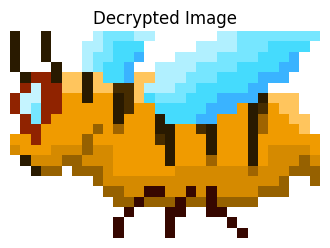

In [13]:
print('--- DECRYPTION ---')
dec_ms = decrypt_image(ENCRYPTED_PATH, DECRYPTED_PATH, SUBKEYS)

print(f"\nTime     : {dec_ms/1000:.2f} s")
print(f"Saved to : {DECRYPTED_PATH}")

plt.figure(figsize=(4,4))
plt.imshow(Image.open(DECRYPTED_PATH))
plt.title('Decrypted Image'); plt.axis('off'); plt.show()

## Cell 14 — Integrity Check
Compare original vs decrypted pixel by pixel.
- **MSE = 0** → perfectly identical
- **PSNR = ∞** → completely lossless

MSE  : 0.000000  (0 = pixel-perfect)
PSNR : inf — lossless

✅ Decryption successful — images are identical!


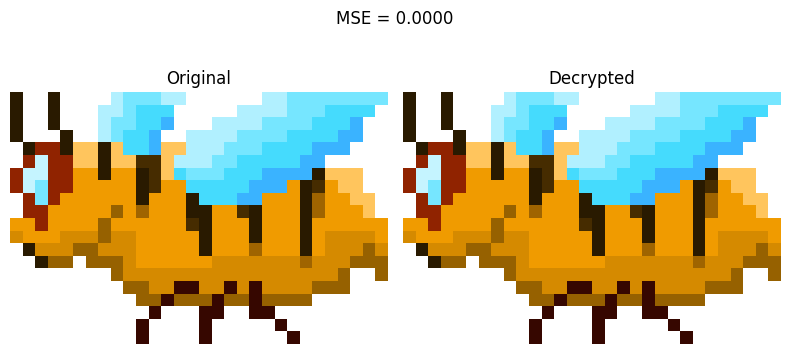

In [14]:
arr1 = np.array(Image.open(IMAGE_PATH)).astype(float)
arr2 = np.array(Image.open(DECRYPTED_PATH)).astype(float)

mse  = np.mean((arr1 - arr2) ** 2)
psnr = float('inf') if mse == 0 else 10 * np.log10(255**2 / mse)

print(f"MSE  : {mse:.6f}  (0 = pixel-perfect)")
print(f"PSNR : {'inf — lossless' if psnr == float('inf') else f'{psnr:.2f} dB'}")

print("\n✅ Decryption successful — images are identical!" if mse == 0 else "\n❌ Mismatch.")

fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(Image.open(IMAGE_PATH));    ax[0].set_title('Original');  ax[0].axis('off')
ax[1].imshow(Image.open(DECRYPTED_PATH));ax[1].set_title('Decrypted'); ax[1].axis('off')
plt.suptitle(f'MSE = {mse:.4f}')
plt.tight_layout(); plt.show()

## Cell 15 — Wrong-Key Test
Try to decrypt with a different key. The result must be unrecognisable garbage, proving that DES cannot be decrypted without the correct key.

In [15]:
print('--- WRONG KEY TEST ---')
wrong_key    = make_des_key('BadKey!!')
wrong_subkeys = generate_subkeys(wrong_key)
print(f"Correct key : {DES_KEY.hex().upper()}")
print(f"Wrong key   : {wrong_key.hex().upper()}")

try:
    decrypt_image(ENCRYPTED_PATH, 'wrong_decrypted.png', wrong_subkeys)
    arr_w = np.array(Image.open('wrong_decrypted.png')).astype(float)
    mse_w = np.mean((arr1 - arr_w) ** 2)
    print(f"\nMSE with wrong key : {mse_w:.2f}  (large number = garbage output)")
    print('✅ Wrong key produces noise — DES is secure.')

    fig, ax = plt.subplots(1,2,figsize=(8,4))
    ax[0].imshow(Image.open(IMAGE_PATH));           ax[0].set_title('Original');         ax[0].axis('off')
    ax[1].imshow(Image.open('wrong_decrypted.png'));ax[1].set_title('Wrong Key (noise)');ax[1].axis('off')
    plt.tight_layout(); plt.show()

except Exception as e:
    print(f"✅ Wrong key caused error: {e}")
    print('Padding check failed — cipher correctly rejects the wrong key.')

--- WRONG KEY TEST ---
Correct key : 5365637265744B79
Wrong key   : 4261644B65792121
  decrypting 1201/1201 blocks...
✅ Wrong key caused error: not enough image data
Padding check failed — cipher correctly rejects the wrong key.


## Cell 16 — Final Side-by-Side Comparison

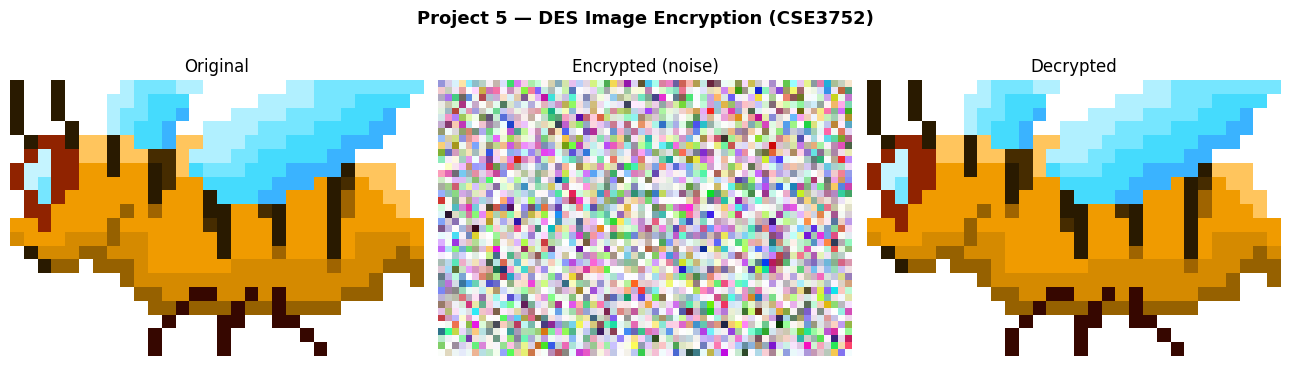

─── Final Summary ───────────────────────────────────────
  Algorithm    : DES only (built from scratch)
  Key          : 'SecretKy' → 5365637265744B79
  Rounds       : 16 Feistel rounds per block
  Block size   : 8 bytes
  Mode         : CBC (random IV each run)
  Padding      : PKCS#7
  Encrypt time : 0.06 s
  Decrypt time : 0.03 s
  MSE          : 0.000000
  Result       : Lossless ✅


In [16]:
fig, axes = plt.subplots(1,3,figsize=(13,4))
axes[0].imshow(Image.open(IMAGE_PATH));    axes[0].set_title('Original',         fontsize=12); axes[0].axis('off')
axes[1].imshow(enc_vis);                   axes[1].set_title('Encrypted (noise)', fontsize=12); axes[1].axis('off')
axes[2].imshow(Image.open(DECRYPTED_PATH));axes[2].set_title('Decrypted',         fontsize=12); axes[2].axis('off')
plt.suptitle('Project 5 — DES Image Encryption (CSE3752)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("─── Final Summary ───────────────────────────────────────")
print(f"  Algorithm    : DES only (built from scratch)")
print(f"  Key          : {KEY_STRING!r} → {DES_KEY.hex().upper()}")
print(f"  Rounds       : 16 Feistel rounds per block")
print(f"  Block size   : 8 bytes")
print(f"  Mode         : CBC (random IV each run)")
print(f"  Padding      : PKCS#7")
print(f"  Encrypt time : {enc_ms/1000:.2f} s")
print(f"  Decrypt time : {dec_ms/1000:.2f} s")
print(f"  MSE          : {mse:.6f}")
print(f"  Result       : {'Lossless ✅' if mse==0 else 'Mismatch ❌'}")